In [89]:
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from typing import TypedDict,Annotated, List
from pydantic import Field,BaseModel
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import operator
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode
from typing import Optional
import serpapi
import os

In [90]:
class TravelState(TypedDict):
    user_input: str = Field(description="Latest user query or message related to travel planning.")
    source: str = Field(description="Departure city or location provided by the user (e.g., Indore, DEL).")
    destination: str = Field(description="Arrival city or destination where the user wants to travel (e.g., Pune, BOM).")
    date_from: str = Field(description="Start date of the trip in YYYY-MM-DD or natural language format.")
    date_to: str = Field(description="End date of the trip in YYYY-MM-DD or natural language format.")
    budget: int = Field(default=0,description="Total budget for the trip in INR. Should be normalized (e.g., '10k' -> 10000).")
    missing_val: List[str] = Field(default_factory=list, description="List of missing required fields among source, destination, date_from, date_to, and budget.")
    missing_question: str = Field(description="Clarification question generated to ask the user for missing trip details.")
    missing_response: str = Field(description="User's response to the clarification question, used to update missing fields.")
    history: Annotated[list, operator.add]
    tools: list
    output: str = Field(description="Final output")

In [91]:

class ParseSchema(BaseModel):
    source: str
    destination: str
    date_from: str
    date_to: str
    missing_val: list[str] = []
    budget: Optional[int] = Field(default=None)


In [92]:
load_dotenv()

small_model = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

versatile_model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

check_model = small_model.with_structured_output(ParseSchema)

In [93]:
search_tool=DuckDuckGoSearchRun()

def flight_tool(source: str, destination: str, date: str):
    """
    Search for available flights between two locations on a given date.

    Args:
        source (str): Departure airport IATA code (MUST be a 3-letter IATA code, e.g., "IDR" for Indore, "DEL" for Delhi).
        destination (str): Arrival airport IATA code (MUST be a 3-letter IATA code, e.g., "GOI" for Goa, "BOM" for Mumbai).
        date (str): Travel date in YYYY-MM-DD format.

    Returns:
        dict: A dictionary containing:
            - status (str): "success" or "error"
            - data (list): List of best available flights
    """
    SERPAPI_KEY = os.getenv("SERPAPI_KEY")
    client = serpapi.Client(api_key=SERPAPI_KEY)
    try:
        results = client.search({
            "engine": "google_flights",
            "departure_id": source,
            "currency": "INR",
            "type": "2",
            "outbound_date": date,
            "arrival_id": destination
        })
        best_flights = results.get("best_flights", [])
        return best_flights
    except Exception as e:
        return f"Error executing flight_tool. This often happens if the travel date is in the past or the IATA codes are invalid. Details: {e}"

tools = [flight_tool,search_tool]
tool_node = ToolNode(tools, messages_key="history")


In [94]:
model_with_tools = versatile_model.bind_tools(tools)

In [95]:
def user_input(state:TravelState):
    user=input("Enter your travel details:")

    return {"user_input":user,"history":[HumanMessage(user)]}

In [96]:
def parse_input_llm(state: TravelState):
    system_prompt = f"""You are an information extraction assistant.

Your task is to read the user_input string and extract these fields:
- source: str
- destination: str
- date_from: str
- date_to: str
- budget: int (optional)
- missing_val: list[str]

Rules:
1. Extract only information explicitly present in the user input.
2. If a string field is not found, set it to "". If an integer field like budget is not found, set it to null.
3. missing_val must contain the names of all fields that are "" or null.
4. If budget is mentioned with words like "10k", convert it to an integer (10000).
5. If dates are mentioned in natural language, convert them to a clear string format with YYYY-MM-DD.
6. Return ONLY valid JSON.
7. Do not include any extra text.
8. Assume year as 2026 year if not mentioned explicitly.
9. If no missing values just return empty list.
10. budget must be a number or None.
11. Do NOT return "null" as a string.

Output format:
{{
  "source": "",
  "destination": "",
  "date_from": "",
  "date_to": "",
  "budget": None,
  "missing_val": []
}}
NOTE: Read history if necessary to find the useful fields from the previous conversation or any update   

History:
{state.get('history', [])}
"""
    res = check_model.invoke([SystemMessage(system_prompt), HumanMessage(state["user_input"])])
    print(dict(res))
    return {
        "source": res.source, 
        "destination": res.destination, 
        "date_from": res.date_from, 
        "budget": res.budget, 
        "date_to": res.date_to, 
        "missing_val": res.missing_val
    }

In [98]:
# state=TravelState(user_input="I want to go to gujrat on 22 oct for 3 days")
# print(parse_input_llm(state))

In [99]:
def missing_check_router(state:TravelState):
    print("--- Executing: missing_check_router ---")
    if(len(state['missing_val'])>0):
        return "ask_missing"
    return "decision_llm"


def ask_missing(state: TravelState):
    print("--- Executing: ask_missing ---")
    prompt = f"""You are a helpful travel assistant.

Your task is to ask the user for missing information required to plan a trip.

Missing fields will be provided as a list:
- source
- destination
- date_from
- date_to
- budget

Rules:
1. Ask ONLY for the missing fields.
2. If multiple fields are missing, combine them into a single natural question.
3. Keep the question short, clear, and conversational.
4. Do NOT mention field names like "date_from" or "date_to" — use natural language.
5. If dates are missing, ask for travel dates together.
6. If budget is missing, ask politely for budget range.
7. Do not ask for fields that are already provided.
8. Return ONLY the question (no JSON, no explanation).

Now generate the question based on:
Missing fields: {state.get('missing_val', [])}"""
    
    res = small_model.invoke(prompt)
    
    return {"missing_question": res.content, "history": [AIMessage(res.content)]}



def update_input(state: TravelState):
    print("--- Executing: update_input ---")
    question = state["missing_question"]
    user = input(question)
    prompt = f"""
You are a travel assistant that updates and summarizes trip details from conversation history.

You are given:
1. Previously extracted trip data
2. A new user response answering missing questions

Your task:
Merge the new response into the previous data and return a COMPLETE, clean, human-readable summary of the trip.

Fields to track:
- source
- destination
- date_from
- date_to
- budget

Rules:
1. Keep all previously filled values unless the user explicitly changes them.
2. Extract any new information from the latest user response.
3. If the user corrects a value, overwrite the old one.
4. Do not remove valid existing data.
5. Convert budget like "10k" → 10000.
6. Normalize dates into a clear readable format.

Output:
- Return a COMPLETE sentence or paragraph describing the trip.
- Include all available details.
- If something is still missing, clearly mention it.

Input:
Previous data:
{state.get('history', [])}

New user response:
{user}
"""
    
    res = small_model.invoke(prompt).content
    
    return {
        "user_input": res, 
        "history": [HumanMessage(res)],
        "missing_question": "",
        "missing_val": [],
        "missing_response": ""
    }

In [100]:
def decision_llm(state: TravelState):
   print("--- Executing: decision_llm ---")
   trip_details = f"""
source: {state.get("source", "")}
destination: {state.get("destination", "")}
date_from: {state.get("date_from", "")}
date_to: {state.get("date_to", "")}
budget: {state.get("budget", "")}
"""

   prompt = f""""You are an intelligent and professional travel planning assistant.

Your task is to analyze the user's request along with the current trip details and decide the next best action.

CURRENT TRIP DETAILS:-
{trip_details}

USER QUERY:-
{state.get('user_input', '')}

AVAILABLE TOOLS:-
- flight_tool: Use to find flights between cities with price, duration, and timing
- duckduckgo_search: Use to find tourist places, attractions, activities, and general travel recommendations


YOUR RESPONSIBILITIES

You must strictly choose ONE of the following actions:

### 1. CALL A TOOL
If all required details are available but you need external data:
- Use flight_tool when user needs transport between cities.
- Use duckduckgo_search when you need tourist attractions, alternative cheaper stays, or general recommendations and trains (if required).
Rules: Call ONLY ONE tool at a time. Do NOT generate final answer while calling a tool.

### 2. GENERATE FINAL ITINERARY
If tools are completed, generate the COMPLETE itinerary. Check if it fits within the user's total budget of {state.get("budget", "")}. If the total cost exceeds the budget, generate the itinerary anyway, BUT ADD a clear WARNING at the very top: '⚠️ The requested itinerary exceeds your budget. Please consider increasing your budget or shortening the trip to optimize this further.'

Include:
1. Travel Summary (Source -> Destination, dates)
2. Transportation (Best flight/train option, Price)
3. Accommodation (Hotels with approx prices)
4. Day-wise Plan
5. Budget Summary (Transport + Stay + Remaining)
6. Best transport to travel in the cities

OUTPUT RULES:
- If calling tool -> return ONLY tool call
- If generating itinerary -> return clean, structured text

Be clear, concise, and helpful."""
    
   messages = [SystemMessage(content=prompt)] + state.get("history", [])
    
   res = model_with_tools.invoke(messages)

   if res.tool_calls:
      return {"history": [res]}
   else:
      return {"output": res.content, "history": [res]}

In [101]:
def check_tools(state: TravelState):
    print("--- Executing: check_tools ---")
    last_message = state.get("history", [])[-1] if state.get("history") else None
    
    if getattr(last_message, "tool_calls", None):
        return "need_tool"
        
    return "generate_output"

In [102]:
state_graph = StateGraph(TravelState)
state_graph.add_node("user_input", user_input)
state_graph.add_node("parse_input_llm", parse_input_llm)
state_graph.add_node("ask_missing", ask_missing)
state_graph.add_node("update_input", update_input)
state_graph.add_node("decision_llm", decision_llm)
state_graph.add_node("tool_node", tool_node)

state_graph.add_edge(START, "user_input")
state_graph.add_edge("user_input", "parse_input_llm")
state_graph.add_conditional_edges("parse_input_llm", missing_check_router, {"decision_llm": "decision_llm", "ask_missing": "ask_missing"})
state_graph.add_edge("tool_node", "decision_llm")
state_graph.add_conditional_edges("decision_llm", check_tools, {"need_tool": "tool_node", "generate_output": END})
state_graph.add_edge("ask_missing", "update_input")
state_graph.add_edge("update_input", "parse_input_llm")

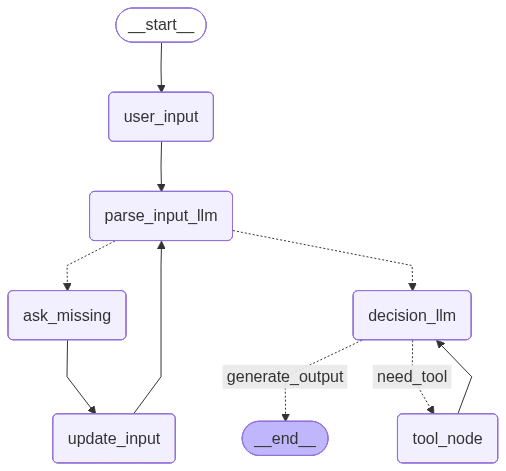

In [103]:
workflow=state_graph.compile()
workflow

In [ ]:
res=workflow.invoke({})
res

{'source': '', 'destination': 'gujrat', 'date_from': '2026-10-22', 'date_to': '', 'missing_val': ['source', 'date_to', 'budget'], 'budget': None}
--- Executing: missing_check_router ---
--- Executing: ask_missing ---
--- Executing: update_input ---
{'source': 'Indore', 'destination': 'Gujarat', 'date_from': '2026-10-22', 'date_to': '2026-10-24', 'missing_val': [], 'budget': 50000}
--- Executing: missing_check_router ---
--- Executing: decision_llm ---
--- Executing: check_tools ---
--- Executing: decision_llm ---
--- Executing: check_tools ---
--- Executing: decision_llm ---
--- Executing: check_tools ---
You’re planning a 3‑day trip from **Indore** to **Gujarat**, departing on **22 October 2026** and returning on **24 October 2026**, with a budget of **₹50,000**.

Travel Summary: 
Indore -> Gujarat 
22 Oct 2026 - 24 Oct 2026

Transportation: 
Best option: 
- Depart from Indore on 22 Oct 2026 at 08:45 and arrive in Ahmedabad on 22 Oct 2026 at 09:55 by 6E 7174 IndiGo flight.
- Depart fr

In [ ]:
print(res['output'])